In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
from google.colab import files
uploaded = files.upload()

Saving amazon dataset nlp.csv to amazon dataset nlp.csv


In [5]:
print("Uploaded files:")
print(list(uploaded.keys()))

Uploaded files:
['amazon dataset nlp.csv']


In [6]:
file_name = 'amazon dataset nlp.csv'

df = pd.read_csv(
    file_name,
    low_memory=False
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
print("Dataset shape:", df.shape)

Dataset shape: (34660, 21)


In [8]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 34660
Columns: 21


In [9]:
display(df.head())

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [10]:
print("Column names:")
print(df.columns.tolist())

Column names:
['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


In [11]:
print("Data types:")
display(df.dtypes)

Data types:


,0
id,object
name,object
asins,object
brand,object
categories,object
keys,object
manufacturer,object
reviews.date,object
reviews.dateAdded,object
reviews.dateSeen,object


In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


,0
id,0
name,6760
asins,2
brand,0
categories,0
keys,0
manufacturer,0
reviews.date,39
reviews.dateAdded,10621
reviews.dateSeen,0


In [13]:
missing_values = df.isnull().sum()

print("Columns containing missing values:")

display(
    missing_values[
        missing_values > 0
    ]
)

Columns containing missing values:


,0
name,6760
asins,2
reviews.date,39
reviews.dateAdded,10621
reviews.didPurchase,34659
reviews.doRecommend,594
reviews.id,34659
reviews.numHelpful,529
reviews.rating,33
reviews.text,1


In [14]:
important_columns = [
    'reviews.text',
    'reviews.title',
    'reviews.rating'
]

display(
    df[important_columns].head(10)
)

,reviews.text,reviews.title,reviews.rating
0,This product so far has not disappointed. My c...,Kindle,5.0
1,great for beginner or experienced person. Boug...,very fast,5.0
2,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,5.0
3,I've had my Fire HD 8 two weeks now and I love...,Good!!!,4.0
4,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,5.0
5,This amazon fire 8 inch tablet is the perfect ...,Just what we expected,5.0
6,"Great for e-reading on the go, nice and light ...",great e-reader tablet,4.0
7,"I gave this as a Christmas gift to my inlaws, ...",Great for gifts,5.0
8,Great as a device to read books. I like that i...,Great for reading,5.0
9,I love ordering books and reading them with th...,Great and lightweight reader,5.0


In [15]:
print(
    "Missing review text:",
    df['reviews.text'].isnull().sum()
)

print(
    "Missing review title:",
    df['reviews.title'].isnull().sum()
)

print(
    "Missing rating:",
    df['reviews.rating'].isnull().sum()
)

Missing review text: 1
Missing review title: 6
Missing rating: 33


In [16]:
df = df.dropna(
    subset=['reviews.text']
)

print(
    "Rows after removing missing review text:",
    len(df)
)

Rows after removing missing review text: 34659


In [17]:
df['reviews.title'] = df[
    'reviews.title'
].fillna('')

print(
    "Missing titles:",
    df['reviews.title'].isnull().sum()
)

Missing titles: 0


In [18]:
df = df.dropna(
    subset=['reviews.rating']
)

print(
    "Rows after removing missing ratings:",
    len(df)
)

Rows after removing missing ratings: 34626


In [20]:
df['reviews.rating'] = pd.to_numeric(
    df['reviews.rating'],
    errors='coerce'
)

In [21]:
df = df.dropna(
    subset=['reviews.rating']
)

print("Current dataset shape:", df.shape)

Current dataset shape: (34626, 21)


In [22]:
print("Rating distribution:")

display(
    df['reviews.rating']
    .value_counts()
    .sort_index()
)

Rating distribution:


,count
reviews.rating,
1.0,410
2.0,402
3.0,1499
4.0,8541
5.0,23774


In [23]:
def create_sentiment(rating):

    if rating <= 2:
        return 'Negative'

    elif rating < 4:
        return 'Neutral'

    else:
        return 'Positive'


df['sentiment'] = df[
    'reviews.rating'
].apply(create_sentiment)

In [24]:
print("Sentiment distribution:")

display(
    df['sentiment'].value_counts()
)

Sentiment distribution:


,count
sentiment,
Positive,32315
Neutral,1499
Negative,812


In [25]:
top_10_products = (
    df['name']
    .value_counts()
    .head(10)
    .index
)

product_sentiment = (
    df[df['name'].isin(top_10_products)]
    .groupby(['name', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

In [26]:
product_sentiment_percentage = (
    product_sentiment
    .div(product_sentiment.sum(axis=1), axis=0)
    * 100
)

) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/2384520902.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


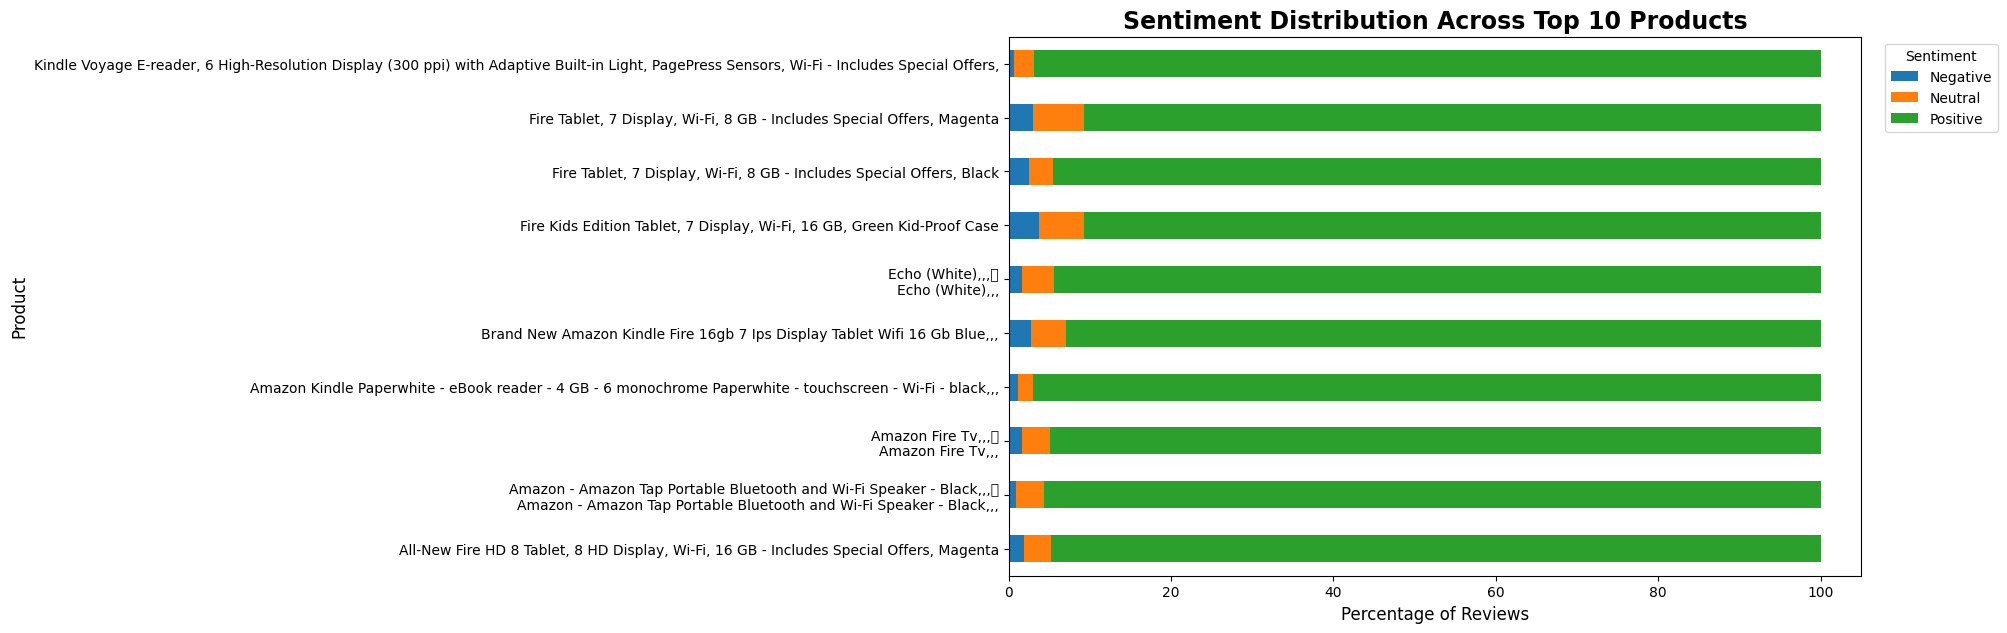

In [27]:
ax = product_sentiment_percentage[
    ['Negative', 'Neutral', 'Positive']
].plot(
    kind='barh',
    stacked=True,
    figsize=(11, 7)
)

plt.title(
    'Sentiment Distribution Across Top 10 Products',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel(
    'Percentage of Reviews',
    fontsize=12
)

plt.ylabel(
    'Product',
    fontsize=12
)

plt.legend(
    title='Sentiment',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [28]:
df['full_review'] = (
    df['reviews.title'].astype(str)
    + ' '
    + df['reviews.text'].astype(str)
)

In [29]:
display(
    df[
        [
            'reviews.title',
            'reviews.text',
            'full_review',
            'sentiment'
        ]
    ].head(10)
)

,reviews.title,reviews.text,full_review,sentiment
0,Kindle,This product so far has not disappointed. My c...,Kindle This product so far has not disappointe...,Positive
1,very fast,great for beginner or experienced person. Boug...,very fast great for beginner or experienced pe...,Positive
2,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son. Inexpe...,Positive
3,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Good!!! I've had my Fire HD 8 two weeks now an...,Positive
4,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,Fantastic Tablet for kids I bought this for my...,Positive
5,Just what we expected,This amazon fire 8 inch tablet is the perfect ...,Just what we expected This amazon fire 8 inch ...,Positive
6,great e-reader tablet,"Great for e-reading on the go, nice and light ...",great e-reader tablet Great for e-reading on t...,Positive
7,Great for gifts,"I gave this as a Christmas gift to my inlaws, ...",Great for gifts I gave this as a Christmas gif...,Positive
8,Great for reading,Great as a device to read books. I like that i...,Great for reading Great as a device to read bo...,Positive
9,Great and lightweight reader,I love ordering books and reading them with th...,Great and lightweight reader I love ordering b...,Positive


In [30]:
def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    # Remove HTML tags
    text = re.sub(
        r'<.*?>',
        '',
        text
    )

    # Remove extra whitespace
    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [31]:
df['clean_review'] = df[
    'full_review'
].apply(clean_text)

In [32]:
display(
    df[
        [
            'full_review',
            'clean_review'
        ]
    ].head(10)
)

,full_review,clean_review
0,Kindle This product so far has not disappointe...,kindle this product so far has not disappointe...
1,very fast great for beginner or experienced pe...,very fast great for beginner or experienced pe...
2,Beginner tablet for our 9 year old son. Inexpe...,beginner tablet for our 9 year old son. inexpe...
3,Good!!! I've had my Fire HD 8 two weeks now an...,good!!! i've had my fire hd 8 two weeks now an...
4,Fantastic Tablet for kids I bought this for my...,fantastic tablet for kids i bought this for my...
5,Just what we expected This amazon fire 8 inch ...,just what we expected this amazon fire 8 inch ...
6,great e-reader tablet Great for e-reading on t...,great e-reader tablet great for e-reading on t...
7,Great for gifts I gave this as a Christmas gif...,great for gifts i gave this as a christmas gif...
8,Great for reading Great as a device to read bo...,great for reading great as a device to read bo...
9,Great and lightweight reader I love ordering b...,great and lightweight reader i love ordering b...


In [33]:
empty_reviews = (
    df['clean_review']
    .str.strip()
    .eq('')
    .sum()
)

print(
    "Number of empty cleaned reviews:",
    empty_reviews
)

Number of empty cleaned reviews: 0


In [34]:
df['word_count'] = (
    df['clean_review']
    .str.split()
    .str.len()
)

In [35]:
df['char_count'] = (
    df['clean_review']
    .str.len()
)

In [36]:
def categorize_review_length(word_count):

    if word_count <= 20:
        return 'Short'

    elif word_count <= 50:
        return 'Medium'

    else:
        return 'Long'


df['review_length_group'] = (
    df['word_count']
    .apply(categorize_review_length)
)

In [37]:
print("Review length groups:")

display(
    df['review_length_group']
    .value_counts()
)

Review length groups:


,count
review_length_group,
Medium,15579
Short,13647
Long,5400


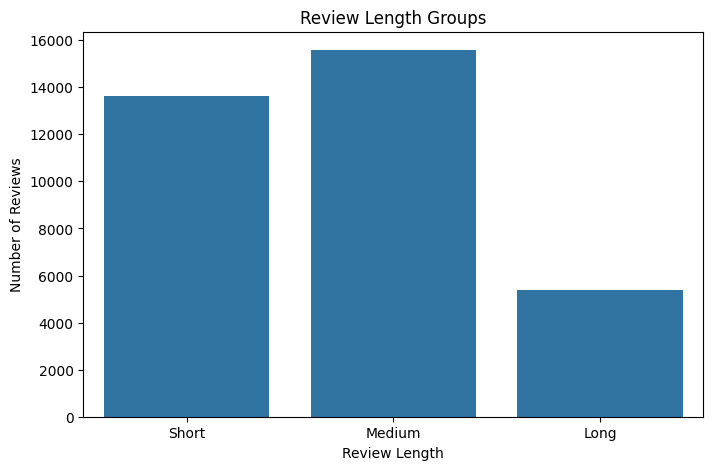

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='review_length_group',
    order=[
        'Short',
        'Medium',
        'Long'
    ]
)

plt.title('Review Length Groups')
plt.xlabel('Review Length')
plt.ylabel('Number of Reviews')

plt.show()

In [39]:
df.to_csv(
    'amazon_reviews_cleaned.csv',
    index=False
)

print(
    "Cleaned dataset saved successfully!"
)

Cleaned dataset saved successfully!


In [40]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['sentiment'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['sentiment'],
    random_state=42
)

In [41]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [42]:
print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

print(
    "\nTotal:",
    len(train_df) +
    len(val_df) +
    len(test_df)
)

Training set: (24238, 27)
Validation set: (5194, 27)
Test set: (5194, 27)

Total: 34626


In [43]:
print("TRAINING SET")
display(
    train_df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nVALIDATION SET")
display(
    val_df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTEST SET")
display(
    test_df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TRAINING SET


,proportion
sentiment,
Positive,93.32
Neutral,4.33
Negative,2.35



VALIDATION SET


,proportion
sentiment,
Positive,93.34
Neutral,4.33
Negative,2.33



TEST SET


,proportion
sentiment,
Positive,93.32
Neutral,4.33
Negative,2.35


In [44]:
train_texts = set(
    train_df['clean_review']
)

val_texts = set(
    val_df['clean_review']
)

test_texts = set(
    test_df['clean_review']
)

print(
    "Train ∩ Validation:",
    len(train_texts & val_texts)
)

print(
    "Train ∩ Test:",
    len(train_texts & test_texts)
)

print(
    "Validation ∩ Test:",
    len(val_texts & test_texts)
)

Train ∩ Validation: 3
Train ∩ Test: 3
Validation ∩ Test: 1


In [45]:
from sklearn.model_selection import train_test_split

# Remove duplicate review texts
df = df.drop_duplicates(subset='clean_review').copy()

# Stratified 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['sentiment'],
    random_state=42
)

# Split remaining 30% equally → 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['sentiment'],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Check sizes
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

# Check text overlap
train_texts = set(train_df['clean_review'])
val_texts = set(val_df['clean_review'])
test_texts = set(test_df['clean_review'])

print("\nText overlap:")
print("Train ∩ Validation:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Validation ∩ Test:", len(val_texts & test_texts))

Train: (24230, 27)
Validation: (5192, 27)
Test: (5193, 27)

Text overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [46]:
train_df.to_csv(
    'train.csv',
    index=False
)

val_df.to_csv(
    'validation.csv',
    index=False
)

test_df.to_csv(
    'test.csv',
    index=False
)

print("Train, validation, and test datasets saved!")

Train, validation, and test datasets saved!


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

X_train = train_df['clean_review']
y_train = train_df['sentiment']

X_val = val_df['clean_review']
y_val = val_df['sentiment']

X_test = test_df['clean_review']
y_test = test_df['sentiment']

In [48]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [49]:
val_pred = model.predict(X_val_tfidf)
test_pred = model.predict(X_test_tfidf)

print("VALIDATION RESULTS")
print(classification_report(y_val, val_pred, digits=4))

print("\nTEST RESULTS")
print(classification_report(y_test, test_pred, digits=4))

print("Test Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Test Macro F1:", round(f1_score(y_test, test_pred, average='macro'), 4))
print("Test Weighted F1:", round(f1_score(y_test, test_pred, average='weighted'), 4))

print("\nTF-IDF shape:", X_train_tfidf.shape)

VALIDATION RESULTS
              precision    recall  f1-score   support

    Negative     0.4045    0.5950    0.4816       121
     Neutral     0.2451    0.4978    0.3284       225
    Positive     0.9794    0.9210    0.9493      4846

    accuracy                         0.8950      5192
   macro avg     0.5430    0.6713    0.5864      5192
weighted avg     0.9342    0.8950    0.9115      5192


TEST RESULTS
              precision    recall  f1-score   support

    Negative     0.4719    0.6885    0.5600       122
     Neutral     0.2581    0.5289    0.3469       225
    Positive     0.9802    0.9212    0.9498      4846

    accuracy                         0.8987      5193
   macro avg     0.5701    0.7129    0.6189      5193
weighted avg     0.9370    0.8987    0.9145      5193

Test Accuracy: 0.8987
Test Macro F1: 0.6189
Test Weighted F1: 0.9145

TF-IDF shape: (24230, 20000)


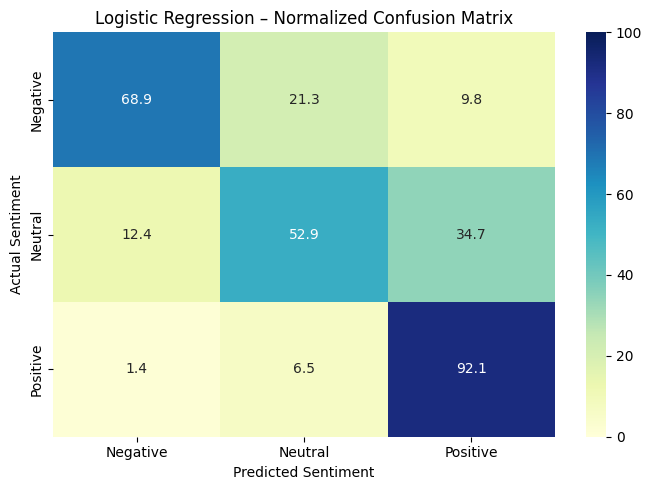

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Normalized confusion matrix
cm = confusion_matrix(
    y_test,
    test_pred,
    labels=['Negative', 'Neutral', 'Positive'],
    normalize='true'
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm * 100,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive'],
    vmin=0,
    vmax=100
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Logistic Regression – Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

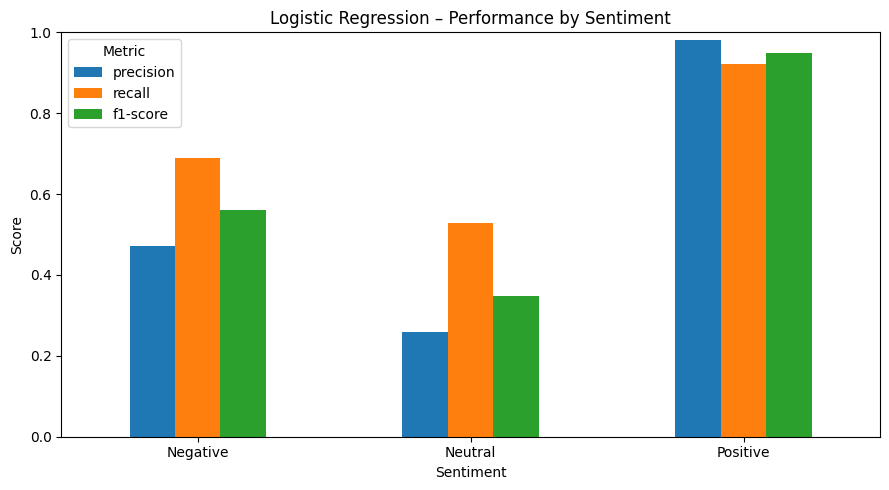

In [51]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Get classification report
report = classification_report(
    y_test,
    test_pred,
    output_dict=True
)

# Create dataframe for the 3 sentiment classes
metrics_df = pd.DataFrame(report).T.loc[
    ['Negative', 'Neutral', 'Positive'],
    ['precision', 'recall', 'f1-score']
]

# Plot
metrics_df.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Logistic Regression – Performance by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [52]:
# Get TF-IDF feature names
feature_names = np.array(tfidf.get_feature_names_out())

# Logistic Regression coefficients
coefficients = model.coef_

classes = model.classes_

# Show top words for each sentiment
for i, sentiment in enumerate(classes):
    top_indices = np.argsort(coefficients[i])[-15:][::-1]

    print(f"\n{'='*40}")
    print(f"TOP FEATURES FOR {sentiment.upper()}")
    print(f"{'='*40}")

    for index in top_indices:
        print(f"{feature_names[index]:25s} {coefficients[i][index]:.4f}")


TOP FEATURES FOR NEGATIVE
not                       5.0648
returned                  3.5930
terrible                  3.4842
not worth                 3.4396
good price                3.1487
never                     3.1067
disappointed              2.9692
one star                  2.9604
slow                      2.9013
star                      2.8100
doesn                     2.7812
grandson he               2.7662
poor                      2.5595
waste                     2.5518
not good                  2.5267

TOP FEATURES FOR NEUTRAL
ok                        4.9213
okay                      4.2556
but                       3.3466
decent                    2.9721
however                   2.3379
sure                      2.2296
good for                  2.1585
limited                   2.0973
not bad                   1.9785
three stars               1.9707
to work                   1.9463
if it                     1.9371
just not                  1.9095
good                   

  Review Length  Precision  Recall      F1
0         Short     0.5951  0.6998  0.6338
1        Medium     0.5623  0.7051  0.6091
2          Long     0.5581  0.7006  0.6014


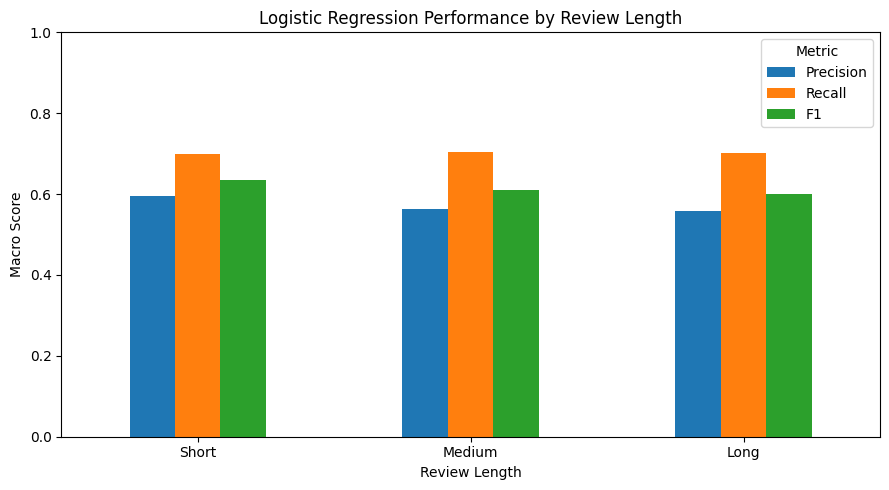

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Create a copy of the test set
audit_df = test_df.copy()

# Add Logistic Regression predictions
audit_df['prediction'] = test_pred

# Calculate metrics for each review-length group
results = []

for group in ['Short', 'Medium', 'Long']:

    group_df = audit_df[audit_df['review_length_group'] == group]

    precision = precision_score(
        group_df['sentiment'],
        group_df['prediction'],
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        group_df['sentiment'],
        group_df['prediction'],
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        group_df['sentiment'],
        group_df['prediction'],
        average='macro',
        zero_division=0
    )

    results.append([group, precision, recall, f1])

# Create results table
results_df = pd.DataFrame(
    results,
    columns=['Review Length', 'Precision', 'Recall', 'F1']
)

print(results_df.round(4))

# Plot
results_df.set_index('Review Length').plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Logistic Regression Performance by Review Length')
plt.xlabel('Review Length')
plt.ylabel('Macro Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [54]:
error_df = test_df.copy()

error_df['prediction'] = test_pred

error_df['correct'] = (
    error_df['sentiment'] == error_df['prediction']
)

print("Total test reviews:", len(error_df))
print("Incorrect predictions:", (~error_df['correct']).sum())
print("Error rate:", round((~error_df['correct']).mean() * 100, 2), "%")

Total test reviews: 5193
Incorrect predictions: 526
Error rate: 10.13 %


In [55]:
errors = error_df[~error_df['correct']].copy()

errors[
    ['clean_review', 'sentiment', 'prediction', 'review_length_group']
].head(20)

,clean_review,sentiment,prediction,review_length_group
10,great for the price i bought this for my daugh...,Positive,Neutral,Medium
11,good speaker honestly i see no difference in t...,Negative,Positive,Short
16,solid tablet gave up old tablet due to battery...,Positive,Neutral,Short
17,great for simple use (not games/apps) i bought...,Positive,Neutral,Long
21,good for teenagers sturdy and easy to use. not...,Positive,Neutral,Short
28,good for kids great little traveling entertain...,Positive,Neutral,Medium
36,exchanged for the voyage i usually read in bed...,Neutral,Positive,Medium
50,good tablets it's a nice tablet for the price ...,Positive,Neutral,Medium
63,fast amazon added ads to this less expensive t...,Positive,Negative,Short
89,good good device4k video is nicegreat supportn...,Positive,Neutral,Short


In [56]:
error_pairs = (
    errors
    .groupby(['sentiment', 'prediction'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

print(error_pairs)

  sentiment prediction  Count
5  Positive    Neutral    316
3   Neutral   Positive     78
4  Positive   Negative     66
2   Neutral   Negative     28
0  Negative    Neutral     26
1  Negative   Positive     12


In [57]:
error_by_length = (
    errors['review_length_group']
    .value_counts()
    .reindex(['Short', 'Medium', 'Long'])
)

print(error_by_length)

review_length_group
Short     142
Medium    231
Long      153
Name: count, dtype: int64


In [58]:
test_prob = model.predict_proba(X_test_tfidf)

error_df['confidence'] = test_prob.max(axis=1)

hard_cases = (
    error_df[~error_df['correct']]
    .sort_values('confidence')
)

hard_cases[
    ['clean_review', 'sentiment', 'prediction', 'confidence']
].head(10)

,clean_review,sentiment,prediction,confidence
3069,cheap feel fully understand this is a budget t...,Negative,Positive,0.336455
2347,"kindle 8 i have had a kindle before, and neede...",Positive,Negative,0.339830
1608,love it shoulded been out along time ago is no...,Positive,Negative,0.346393
1311,excellent picture this is probably one of the ...,Positive,Negative,0.346592
3209,not for those who wants to read free epub book...,Negative,Neutral,0.360856
2022,cheap tablet for kids i wish i purchased the w...,Positive,Neutral,0.361126
1649,bloaaattted wish the kindle fire (for kids) ha...,Positive,Neutral,0.363730
4489,good gift for christmas i bought this tablet f...,Positive,Negative,0.373197
3447,not worth the price bought this an an auxiliar...,Neutral,Positive,0.377402
1288,cheap tablet i got this because is difficult t...,Positive,Negative,0.377479


In [59]:
hard_cases[
    ['clean_review', 'sentiment', 'prediction', 'confidence']
].head(10)

,clean_review,sentiment,prediction,confidence
3069,cheap feel fully understand this is a budget t...,Negative,Positive,0.336455
2347,"kindle 8 i have had a kindle before, and neede...",Positive,Negative,0.339830
1608,love it shoulded been out along time ago is no...,Positive,Negative,0.346393
1311,excellent picture this is probably one of the ...,Positive,Negative,0.346592
3209,not for those who wants to read free epub book...,Negative,Neutral,0.360856
2022,cheap tablet for kids i wish i purchased the w...,Positive,Neutral,0.361126
1649,bloaaattted wish the kindle fire (for kids) ha...,Positive,Neutral,0.363730
4489,good gift for christmas i bought this tablet f...,Positive,Negative,0.373197
3447,not worth the price bought this an an auxiliar...,Neutral,Positive,0.377402
1288,cheap tablet i got this because is difficult t...,Positive,Negative,0.377479


In [60]:

# BiLSTM - Step 1: Imports and Setup


import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("BiLSTM libraries imported successfully.")

TensorFlow version: 2.21.0
BiLSTM libraries imported successfully.


In [61]:

# BiLSTM - Step 2: Review Length Analysis


# Calculate basic statistics of review length
print("Review length statistics:")
print(train_df['word_count'].describe())

# Calculate useful percentiles
percentiles = train_df['word_count'].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

print("\nReview length percentiles:")
display(percentiles)

# Check how many reviews exceed possible sequence lengths
for length in [50, 75, 100, 150, 200]:
    percentage = (
        train_df['word_count'] > length
    ).mean() * 100

    print(
        f"Reviews longer than {length} words: "
        f"{percentage:.2f}%"
    )

Review length statistics:
count    24230.000000
mean        33.864383
std         34.752082
min          2.000000
25%         17.000000
50%         24.000000
75%         39.000000
max       1868.000000
Name: word_count, dtype: float64

Review length percentiles:


,word_count
0.50,24.0
0.75,39.0
0.90,63.0
0.95,84.0
0.99,162.0


Reviews longer than 50 words: 15.62%
Reviews longer than 75 words: 6.64%
Reviews longer than 100 words: 3.29%
Reviews longer than 150 words: 1.19%
Reviews longer than 200 words: 0.64%


In [62]:

# BiLSTM - Step 3: Tokenization


MAX_LEN = 100

# Create tokenizer
tokenizer = Tokenizer(
    oov_token="<OOV>"
)

# Fit ONLY on training reviews
tokenizer.fit_on_texts(X_train)

# Convert train/validation/test reviews to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)

print("\nExample tokenized review:")
print(X_train_seq[0][:30])

print("\nOriginal review:")
print(X_train.iloc[0][:300])

Vocabulary size: 12794

Example tokenized review:
[55, 157, 425, 2, 27, 34, 47, 157, 10, 2, 55, 529, 5, 95, 153, 6, 640, 1363, 40, 222, 250, 4, 6, 43, 8, 9, 222, 512, 6, 43]

Original review:
best box option... the amazon fire tv box is the best choice for your money. it runs smoothly, it's user friendly and it has a great user interface. it has 2gb of memory which is a plus, and it allows you to connect directly to your modem via ethernet. i find this especially helpful when you are hav


In [63]:

# BiLSTM - Step 4: Padding

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

# Convert labels to NumPy arrays
y_train_bilstm = np.array(y_train)
y_val_bilstm = np.array(y_val)
y_test_bilstm = np.array(y_test)

print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

print("\nLabel shapes:")
print("y_train:", y_train_bilstm.shape)
print("y_val:", y_val_bilstm.shape)
print("y_test:", y_test_bilstm.shape)

print("\nExample padded sequence:")
print(X_train_pad[0])

Train shape: (24230, 100)
Validation shape: (5192, 100)
Test shape: (5193, 100)

Label shapes:
y_train: (24230,)
y_val: (5192,)
y_test: (5193,)

Example padded sequence:
[  55  157  425    2   27   34   47  157   10    2   55  529    5   95
  153    6  640 1363   40  222  250    4    6   43    8    9  222  512
    6   43 4134   14  263  147   10    8  331    4    6  496   19    3
  453 1049    3   95 2138  721  911    7  232   12  283  417   83   19
   48  194  325   15   95  271   62   19   20  155  246   23   95  110
  586    3   95  271    7   20   35   70  133  325   15   12  157    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [64]:

# BiLSTM - Step 5A: Build and Compile Model


from tensorflow.keras import Input

EMBEDDING_DIM = 128
LSTM_UNITS = 64

bilstm_model = Sequential([
    Input(shape=(MAX_LEN,), dtype="int32"),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(LSTM_UNITS)
    ),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(3, activation='softmax')
])

# Compile the model
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display architecture
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,637,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,675 (6.64 MB)

 Trainable params: 1,740,675 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:

# Check BiLSTM label format


print("y_train type:", type(y_train))
print("y_train dtype:", y_train.dtype)

print("\nUnique y_train values:")
print(y_train.unique())

print("\nFirst 10 labels:")
print(y_train.head(10).tolist())

y_train type: <class 'pandas.core.series.Series'>
y_train dtype: object

Unique y_train values:
['Positive' 'Neutral' 'Negative']

First 10 labels:
['Positive', 'Positive', 'Positive', 'Neutral', 'Positive', 'Positive', 'Positive', 'Positive', 'Negative', 'Positive']


In [70]:

# BiLSTM - Step 5B.2: Encode Sentiment Labels


label_mapping = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

# Convert string labels to integer labels
y_train_bilstm = y_train.map(label_mapping).astype('int32')
y_val_bilstm = y_val.map(label_mapping).astype('int32')
y_test_bilstm = y_test.map(label_mapping).astype('int32')

# Verify the conversion
print("Original labels:")
print(y_train.head(10).tolist())

print("\nEncoded labels:")
print(y_train_bilstm.head(10).tolist())

print("\nEncoded label distribution:")
print(y_train_bilstm.value_counts().sort_index())

print("\nUnique encoded labels:")
print(sorted(y_train_bilstm.unique()))

Original labels:
['Positive', 'Positive', 'Positive', 'Neutral', 'Positive', 'Positive', 'Positive', 'Positive', 'Negative', 'Positive']

Encoded labels:
[2, 2, 2, 1, 2, 2, 2, 2, 0, 2]

Encoded label distribution:
sentiment
0      567
1     1049
2    22614
Name: count, dtype: int64

Unique encoded labels:
[np.int32(0), np.int32(1), np.int32(2)]


In [68]:

# BiLSTM - Step 5B: Training

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train_bilstm,
    validation_data=(X_val_pad, y_val_bilstm),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 91s 230ms/step - accuracy: 0.9334 - loss: 0.2447 - val_accuracy: 0.9393 - val_loss: 0.1804
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 145s 238ms/step - accuracy: 0.9426 - loss: 0.1670 - val_accuracy: 0.9422 - val_loss: 0.1835
Epoch 3/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 91s 239ms/step - accuracy: 0.9534 - loss: 0.1352 - val_accuracy: 0.9405 - val_loss: 0.2325


In [71]:

# BiLSTM - Step 6: Test Evaluation


# Evaluate on the untouched test set
test_loss, test_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test_bilstm,
    verbose=1
)

print("\nBiLSTM Test Results")
print("-------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9386 - loss: 0.1793

BiLSTM Test Results
-------------------
Test Loss: 0.1793
Test Accuracy: 0.9386


In [72]:

# BiLSTM - Step 6B: Classification Report


# Generate predictions
y_pred_bilstm_prob = bilstm_model.predict(
    X_test_pad,
    verbose=1
)

# Convert probabilities to predicted class IDs
y_pred_bilstm = np.argmax(
    y_pred_bilstm_prob,
    axis=1
)

# Classification report
print("BiLSTM Classification Report")
print("=============================")

print(
    classification_report(
        y_test_bilstm,
        y_pred_bilstm,
        target_names=['Negative', 'Neutral', 'Positive'],
        digits=4
    )
)

163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step
BiLSTM Classification Report
              precision    recall  f1-score   support

    Negative     0.6875    0.0902    0.1594       122
     Neutral     0.4146    0.2267    0.2931       225
    Positive     0.9521    0.9930    0.9721      4846

    accuracy                         0.9386      5193
   macro avg     0.6848    0.4366    0.4749      5193
weighted avg     0.9226    0.9386    0.9236      5193



In [74]:

# BiLSTM - Step 6D: Save Results

bilstm_results = {
    'Model': 'BiLSTM',
    'Accuracy': test_accuracy,
    'Macro_F1': f1_score(
        y_test_bilstm,
        y_pred_bilstm,
        average='macro'
    ),
    'Weighted_F1': f1_score(
        y_test_bilstm,
        y_pred_bilstm,
        average='weighted'
    )
}

print("BiLSTM results saved:")
print(bilstm_results)

BiLSTM results saved:
{'Model': 'BiLSTM', 'Accuracy': 0.9385711550712585, 'Macro_F1': 0.47488165008404887, 'Weighted_F1': 0.923608115764256}


In [75]:
# ============================================
# MODEL COMPARISON
# Logistic Regression vs BiLSTM
# ============================================

# Logistic Regression results from the existing pipeline
logistic_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, test_pred),
    'Macro_F1': f1_score(
        y_test,
        test_pred,
        average='macro'
    ),
    'Weighted_F1': f1_score(
        y_test,
        test_pred,
        average='weighted'
    )
}

# Combine both models
model_comparison = pd.DataFrame([
    logistic_results,
    bilstm_results
])

# Display rounded results
model_comparison_display = model_comparison.copy()

for col in ['Accuracy', 'Macro_F1', 'Weighted_F1']:
    model_comparison_display[col] = (
        model_comparison_display[col] * 100
    ).round(2)

print("MODEL COMPARISON")
print("================")

display(model_comparison_display)

MODEL COMPARISON


,Model,Accuracy,Macro_F1,Weighted_F1
0,Logistic Regression,89.87,61.89,91.45
1,BiLSTM,93.86,47.49,92.36


BiLSTM Performance by Review Length


,Review Length,Reviews,Precision,Recall,F1
0,Short,2028,0.4559,0.4182,0.4321
1,Medium,2342,0.7952,0.4187,0.4556
2,Long,823,0.6448,0.4626,0.5020


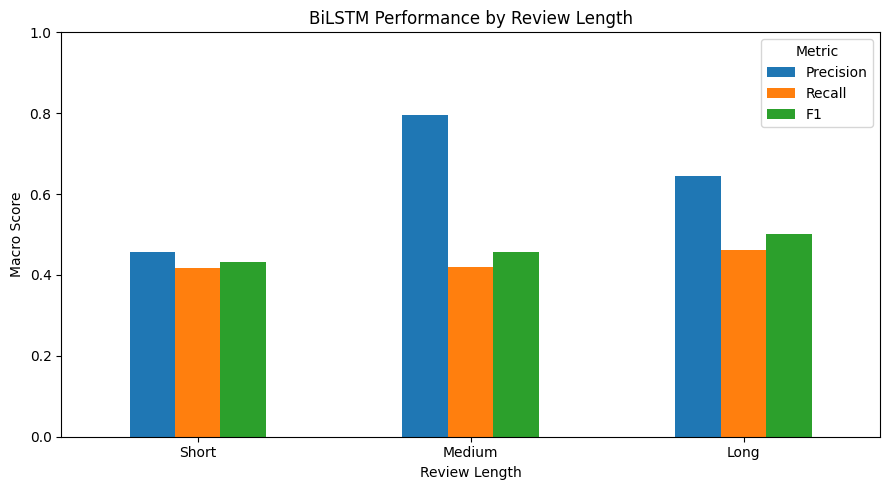

In [76]:
# ============================================
# BiLSTM - Review Length Audit
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Create audit dataframe
bilstm_audit = test_df.copy()

# Convert numeric predictions back to sentiment labels
label_names = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}

bilstm_audit['prediction'] = (
    pd.Series(y_pred_bilstm, index=bilstm_audit.index)
    .map(label_names)
)

results_bilstm = []

for group in ['Short', 'Medium', 'Long']:

    group_df = bilstm_audit[
        bilstm_audit['review_length_group'] == group
    ]

    precision = precision_score(
        group_df['sentiment'],
        group_df['prediction'],
        labels=['Negative', 'Neutral', 'Positive'],
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        group_df['sentiment'],
        group_df['prediction'],
        labels=['Negative', 'Neutral', 'Positive'],
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        group_df['sentiment'],
        group_df['prediction'],
        labels=['Negative', 'Neutral', 'Positive'],
        average='macro',
        zero_division=0
    )

    results_bilstm.append([
        group,
        len(group_df),
        precision,
        recall,
        f1
    ])

bilstm_length_results = pd.DataFrame(
    results_bilstm,
    columns=[
        'Review Length',
        'Reviews',
        'Precision',
        'Recall',
        'F1'
    ]
)

print("BiLSTM Performance by Review Length")
display(
    bilstm_length_results.round(4)
)

# Plot
bilstm_length_results.set_index(
    'Review Length'
)[['Precision', 'Recall', 'F1']].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('BiLSTM Performance by Review Length')
plt.xlabel('Review Length')
plt.ylabel('Macro Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [77]:
# ============================================
# BiLSTM - Error Analysis
# ============================================

# Create error-analysis dataframe
bilstm_errors = test_df.copy()

# Convert numeric labels to sentiment names
label_names = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}

bilstm_errors['actual'] = y_test_bilstm.map(label_names)
bilstm_errors['predicted'] = pd.Series(
    y_pred_bilstm,
    index=test_df.index
).map(label_names)

# Prediction confidence
bilstm_errors['confidence'] = np.max(
    y_pred_bilstm_prob,
    axis=1
)

# Correct / incorrect
bilstm_errors['correct'] = (
    bilstm_errors['actual'] ==
    bilstm_errors['predicted']
)

# --------------------------------------------
# 1. Total errors
# --------------------------------------------

print("BiLSTM Error Analysis")
print("=====================")

print("Total test reviews:", len(bilstm_errors))
print("Total errors:", (~bilstm_errors['correct']).sum())

# --------------------------------------------
# 2. Dominant confusion pairs
# --------------------------------------------

confusion_pairs = (
    bilstm_errors[~bilstm_errors['correct']]
    .groupby(['actual', 'predicted'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

print("\nDominant Confusion Pairs")
print("========================")

display(confusion_pairs)

# --------------------------------------------
# 3. Errors by review length
# --------------------------------------------

length_errors = (
    bilstm_errors[~bilstm_errors['correct']]
    .groupby('review_length_group')
    .size()
    .reindex(['Short', 'Medium', 'Long'], fill_value=0)
    .reset_index(name='Error Count')
)

print("\nErrors by Review Length")
print("=======================")

display(length_errors)

# --------------------------------------------
# 4. Low-confidence incorrect predictions
# --------------------------------------------

low_confidence_errors = (
    bilstm_errors[~bilstm_errors['correct']]
    .sort_values('confidence')
)

print("\nLowest-Confidence Incorrect Predictions")
print("=======================================")

display(
    low_confidence_errors[
        [
            'clean_review',
            'actual',
            'predicted',
            'confidence',
            'review_length_group'
        ]
    ].head(10)
)

BiLSTM Error Analysis
Total test reviews: 5193
Total errors: 319

Dominant Confusion Pairs


,actual,predicted,Count
3,Neutral,Positive,173
1,Negative,Positive,69
0,Negative,Neutral,42
5,Positive,Neutral,30
4,Positive,Negative,4
2,Neutral,Negative,1



Errors by Review Length


,review_length_group,Error Count
0,Short,91
1,Medium,131
2,Long,97



Lowest-Confidence Incorrect Predictions


,clean_review,actual,predicted,confidence,review_length_group
4111,almost... it's somewhat of a step up from the ...,Negative,Neutral,0.341682,Long
3152,good for basic use purchased blue unit - paren...,Neutral,Positive,0.349214,Long
70,ok tablet for kids i purchased these tablets f...,Positive,Neutral,0.349409,Long
1957,ok works.........................................,Positive,Neutral,0.349833,Short
1358,crazy pop ups didn't like it. to many pop up a...,Negative,Neutral,0.350741,Short
2485,no screen my daughter got this for christmas. ...,Negative,Positive,0.351305,Medium
2047,not what i expected if you don't care about li...,Negative,Positive,0.352296,Medium
2014,operating system. wasnt really impressed with ...,Negative,Neutral,0.352487,Short
4937,"one amp, not a good thing i dont own this, fir...",Negative,Neutral,0.353200,Long
1840,extreme disappointment not sure what all the h...,Negative,Positive,0.353670,Medium


High-Confidence Correct Predictions


,clean_review,actual,predicted,confidence
2377,love love love!!! this thing is awesome!!! its...,Positive,Positive,0.999602
2578,love love love i use this item mostly for musi...,Positive,Positive,0.999510
4004,awesome! love using the echo to add stuff to m...,Positive,Positive,0.999363
3960,awesome great electronic! great size! great qu...,Positive,Positive,0.999343
2667,love my echo love my echo. set up was simple a...,Positive,Positive,0.999313



Low-Confidence Incorrect Predictions


,clean_review,actual,predicted,confidence
4111,almost... it's somewhat of a step up from the ...,Negative,Neutral,0.341682
3152,good for basic use purchased blue unit - paren...,Neutral,Positive,0.349214
70,ok tablet for kids i purchased these tablets f...,Positive,Neutral,0.349409
1957,ok works.........................................,Positive,Neutral,0.349833
1358,crazy pop ups didn't like it. to many pop up a...,Negative,Neutral,0.350741


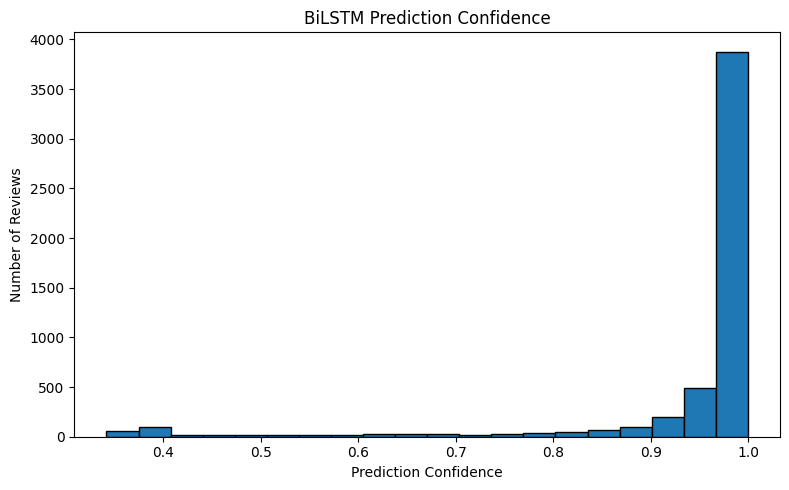

In [78]:
# ============================================
# BiLSTM - Explainability
# ============================================

# Sort predictions by confidence
bilstm_explain = bilstm_errors.sort_values(
    'confidence',
    ascending=False
)

# --------------------------------------------
# 1. High-confidence correct predictions
# --------------------------------------------

high_conf_correct = bilstm_explain[
    bilstm_explain['correct'] == True
].head(5)

print("High-Confidence Correct Predictions")
print("===================================")

display(
    high_conf_correct[
        [
            'clean_review',
            'actual',
            'predicted',
            'confidence'
        ]
    ]
)

# --------------------------------------------
# 2. Low-confidence incorrect predictions
# --------------------------------------------

low_conf_errors = bilstm_explain[
    bilstm_explain['correct'] == False
].sort_values(
    'confidence',
    ascending=True
).head(5)

print("\nLow-Confidence Incorrect Predictions")
print("====================================")

display(
    low_conf_errors[
        [
            'clean_review',
            'actual',
            'predicted',
            'confidence'
        ]
    ]
)

# --------------------------------------------
# 3. Confidence distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    bilstm_errors['confidence'],
    bins=20,
    edgecolor='black'
)

plt.title('BiLSTM Prediction Confidence')
plt.xlabel('Prediction Confidence')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

In [79]:
# ============================================
# Final Model Comparison
# ============================================

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, test_pred)
lr_macro_f1 = f1_score(y_test, test_pred, average='macro')
lr_weighted_f1 = f1_score(y_test, test_pred, average='weighted')

# BiLSTM metrics
bilstm_accuracy = accuracy_score(y_test_bilstm, y_pred_bilstm)
bilstm_macro_f1 = f1_score(y_test_bilstm, y_pred_bilstm, average='macro')
bilstm_weighted_f1 = f1_score(y_test_bilstm, y_pred_bilstm, average='weighted')

# Comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'BiLSTM',
        'DistilBERT'
    ],
    'Accuracy': [
        lr_accuracy,
        bilstm_accuracy,
        np.nan
    ],
    'Macro F1': [
        lr_macro_f1,
        bilstm_macro_f1,
        np.nan
    ],
    'Weighted F1': [
        lr_weighted_f1,
        bilstm_weighted_f1,
        np.nan
    ],
    'Status': [
        'Implemented',
        'Implemented',
        'Not implemented - computational constraints'
    ]
})

display(model_comparison)

,Model,Accuracy,Macro F1,Weighted F1,Status
0,TF-IDF + Logistic Regression,0.898710,0.618909,0.914510,Implemented
1,BiLSTM,0.938571,0.474882,0.923608,Implemented
2,DistilBERT,NaN,NaN,NaN,Not implemented - computational constraints


In [80]:
# ============================================
# Model Comparison by Review Length
# ============================================

# Logistic Regression predictions
lr_audit = test_df.copy()
lr_audit['actual'] = pd.Series(y_test, index=test_df.index)
lr_audit['predicted'] = pd.Series(test_pred, index=test_df.index)

# BiLSTM predictions
bilstm_audit = test_df.copy()
bilstm_audit['actual'] = pd.Series(y_test_bilstm, index=test_df.index)
bilstm_audit['predicted'] = pd.Series(y_pred_bilstm, index=test_df.index)

# Calculate macro F1 for each review-length group
comparison_results = []

for group in ['Short', 'Medium', 'Long']:

    # Logistic Regression
    lr_group = lr_audit[lr_audit['review_length_group'] == group]

    lr_f1 = f1_score(
        lr_group['actual'],
        lr_group['predicted'],
        average='macro',
        zero_division=0
    )

    # BiLSTM
    bilstm_group = bilstm_audit[
        bilstm_audit['review_length_group'] == group
    ]

    bilstm_f1 = f1_score(
        bilstm_group['actual'],
        bilstm_group['predicted'],
        average='macro',
        zero_division=0
    )

    comparison_results.append({
        'Review Length': group,
        'Logistic Regression Macro F1': lr_f1,
        'BiLSTM Macro F1': bilstm_f1
    })

length_comparison = pd.DataFrame(comparison_results)

display(length_comparison)

,Review Length,Logistic Regression Macro F1,BiLSTM Macro F1
0,Short,0.633825,0.432124
1,Medium,0.609106,0.455598
2,Long,0.601430,0.502037


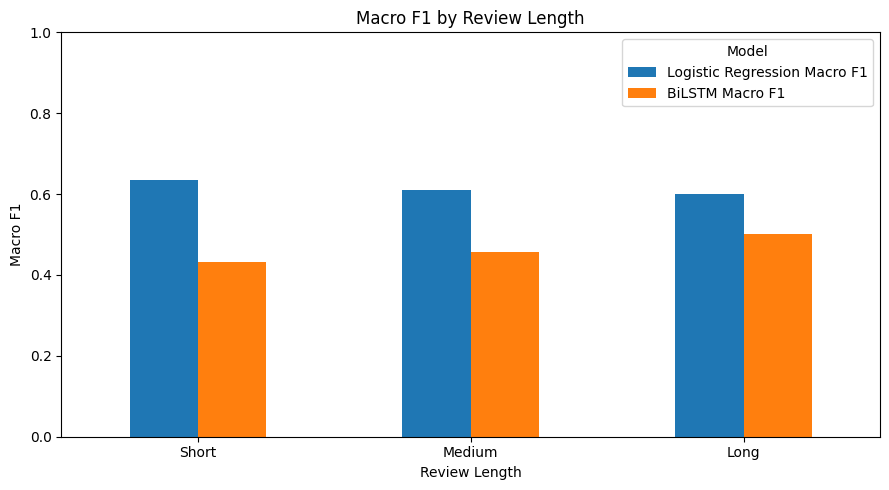

In [81]:
# ============================================
# Review Length Performance Comparison
# ============================================

length_comparison.set_index('Review Length')[
    ['Logistic Regression Macro F1', 'BiLSTM Macro F1']
].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Macro F1 by Review Length')
plt.xlabel('Review Length')
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [82]:
# ============================================
# Error Pattern Comparison
# ============================================

label_names = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}

# Logistic Regression errors
lr_errors = pd.DataFrame({
    'actual': pd.Series(y_test, index=test_df.index).map(label_names),
    'predicted': pd.Series(test_pred, index=test_df.index).map(label_names)
})

lr_errors['correct'] = (
    lr_errors['actual'] == lr_errors['predicted']
)

# BiLSTM errors
bilstm_errors_compare = pd.DataFrame({
    'actual': pd.Series(y_test_bilstm, index=test_df.index).map(label_names),
    'predicted': pd.Series(y_pred_bilstm, index=test_df.index).map(label_names)
})

bilstm_errors_compare['correct'] = (
    bilstm_errors_compare['actual'] ==
    bilstm_errors_compare['predicted']
)

# Count incorrect prediction pairs
lr_confusions = (
    lr_errors[~lr_errors['correct']]
    .groupby(['actual', 'predicted'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

bilstm_confusions = (
    bilstm_errors_compare[~bilstm_errors_compare['correct']]
    .groupby(['actual', 'predicted'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

print("Logistic Regression - Most Common Errors")
display(lr_confusions.head(10))

print("BiLSTM - Most Common Errors")
display(bilstm_confusions.head(10))

Logistic Regression - Most Common Errors


,actual,predicted,Count


BiLSTM - Most Common Errors


,actual,predicted,Count
3,Neutral,Positive,173
1,Negative,Positive,69
0,Negative,Neutral,42
5,Positive,Neutral,30
4,Positive,Negative,4
2,Neutral,Negative,1


In [83]:
# ============================================
# Final Audit Summary
# ============================================

# Overall performance
overall_audit = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'BiLSTM'
    ],
    'Accuracy': [
        accuracy_score(y_test, test_pred),
        accuracy_score(y_test_bilstm, y_pred_bilstm)
    ],
    'Macro F1': [
        f1_score(y_test, test_pred, average='macro'),
        f1_score(y_test_bilstm, y_pred_bilstm, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, test_pred, average='weighted'),
        f1_score(y_test_bilstm, y_pred_bilstm, average='weighted')
    ]
})

display(overall_audit)

,Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.898710,0.618909,0.914510
1,BiLSTM,0.938571,0.474882,0.923608


In [84]:
# ============================================
# Audit Findings by Review Length
# ============================================

audit_findings = length_comparison.copy()

audit_findings['F1 Difference (BiLSTM - LR)'] = (
    audit_findings['BiLSTM Macro F1']
    - audit_findings['Logistic Regression Macro F1']
)

display(audit_findings)# ============================================
# Audit Findings by Review Length
# ============================================

audit_findings = length_comparison.copy()

audit_findings['F1 Difference (BiLSTM - LR)'] = (
    audit_findings['BiLSTM Macro F1']
    - audit_findings['Logistic Regression Macro F1']
)

display(audit_findings)

,Review Length,Logistic Regression Macro F1,BiLSTM Macro F1,F1 Difference (BiLSTM - LR)
0,Short,0.633825,0.432124,-0.201701
1,Medium,0.609106,0.455598,-0.153509
2,Long,0.601430,0.502037,-0.099393


,Review Length,Logistic Regression Macro F1,BiLSTM Macro F1,F1 Difference (BiLSTM - LR)
0,Short,0.633825,0.432124,-0.201701
1,Medium,0.609106,0.455598,-0.153509
2,Long,0.601430,0.502037,-0.099393


In [85]:
# ============================================
# Model Card - Amazon Review Sentiment Analysis
# ============================================

model_card = """
MODEL CARD: AMAZON REVIEW SENTIMENT ANALYSIS
============================================

1. MODEL OVERVIEW
-----------------
Task:
3-class sentiment classification of Amazon product reviews.

Sentiment labels:
- Negative: 1–2 stars
- Neutral: 3 stars
- Positive: 4–5 stars

Implemented models:
1. TF-IDF + Logistic Regression
2. BiLSTM

DistilBERT:
Considered but not implemented because fine-tuning a transformer
required more computational resources than were available.

2. INTENDED USE
---------------
The models are intended for educational analysis of sentiment in
Amazon product reviews. They can be used to study patterns in
customer review text and compare traditional machine learning with
deep learning approaches.

The models should not be treated as perfect representations of
customer opinions or used as the sole basis for important decisions.

3. DATASET
----------
Dataset:
Amazon product review dataset.

The dataset contains review text, ratings, product information,
and other metadata.

Sentiment distribution is highly imbalanced, with Positive reviews
representing the large majority of the dataset.

To reduce data leakage, duplicate review texts were removed before
the final train/validation/test split.

4. PREPROCESSING
----------------
- Review title and review text were combined.
- Text was converted to lowercase.
- URLs and HTML tags were removed.
- Whitespace was normalized.
- Stopword removal was avoided because words such as "not" can
  be important for sentiment classification.
- Reviews were grouped by length:
  Short: <= 20 words
  Medium: 21–50 words
  Long: > 50 words

The data was split using a stratified 70/15/15 train/validation/test
split.

5. PERFORMANCE
---------------
Primary evaluation metric:
Macro F1.

Macro F1 was emphasized because the sentiment classes are highly
imbalanced.

Additional metrics:
- Accuracy
- Weighted F1
- Precision
- Recall
- Class-wise F1

The final numerical results are reported in the model comparison
table generated during evaluation.

6. AUDIT
--------
Subgroup audit:
Performance was evaluated separately for Short, Medium, and Long
reviews.

Error analysis:
Common actual-vs-predicted confusion pairs were examined for both
implemented models.

Explainability:
Logistic Regression was examined using model coefficients to identify
features associated with the different sentiment classes.

For the BiLSTM, prediction confidence and representative correct
and incorrect predictions were examined.

7. LIMITATIONS
--------------
- The dataset has severe class imbalance.
- Star ratings are used as a proxy for textual sentiment.
- A 3-star review may contain mixed or nuanced opinions.
- Sarcasm and context-dependent language can be difficult to classify.
- Review length may affect model performance.
- The dataset may not represent all customers, products, or review
  platforms.
- High prediction confidence does not guarantee a correct prediction.
- DistilBERT was not implemented because of computational constraints.

8. RESPONSIBLE AI CONSIDERATIONS
--------------------------------
Model predictions should be interpreted as automated estimates of
sentiment rather than definitive judgments about customers.

Performance should be considered across different review groups
rather than relying only on overall accuracy.

The severe class imbalance means that majority-class performance can
make accuracy appear stronger than performance on minority classes.
Therefore, Macro F1 and class-level metrics are important when
interpreting results.
"""

print(model_card)


MODEL CARD: AMAZON REVIEW SENTIMENT ANALYSIS

1. MODEL OVERVIEW
-----------------
Task:
3-class sentiment classification of Amazon product reviews.

Sentiment labels:
- Negative: 1–2 stars
- Neutral: 3 stars
- Positive: 4–5 stars

Implemented models:
1. TF-IDF + Logistic Regression
2. BiLSTM

DistilBERT:
Considered but not implemented because fine-tuning a transformer
required more computational resources than were available.

2. INTENDED USE
---------------
The models are intended for educational analysis of sentiment in
Amazon product reviews. They can be used to study patterns in
customer review text and compare traditional machine learning with
deep learning approaches.

The models should not be treated as perfect representations of
customer opinions or used as the sole basis for important decisions.

3. DATASET
----------
Dataset:
Amazon product review dataset.

The dataset contains review text, ratings, product information,
and other metadata.

Sentiment distribution is highly i

In [86]:
# ============================================
# Presentation-Ready Model Comparison
# ============================================

final_comparison = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'BiLSTM',
        'DistilBERT'
    ],
    'Accuracy': [
        accuracy_score(y_test, test_pred),
        accuracy_score(y_test_bilstm, y_pred_bilstm),
        np.nan
    ],
    'Macro F1': [
        f1_score(y_test, test_pred, average='macro'),
        f1_score(y_test_bilstm, y_pred_bilstm, average='macro'),
        np.nan
    ],
    'Weighted F1': [
        f1_score(y_test, test_pred, average='weighted'),
        f1_score(y_test_bilstm, y_pred_bilstm, average='weighted'),
        np.nan
    ],
    'Status': [
        'Implemented',
        'Implemented',
        'Not implemented'
    ]
})

# Round numerical values
final_comparison[
    ['Accuracy', 'Macro F1', 'Weighted F1']
] = final_comparison[
    ['Accuracy', 'Macro F1', 'Weighted F1']
].round(3)

display(final_comparison)

,Model,Accuracy,Macro F1,Weighted F1,Status
0,TF-IDF + Logistic Regression,0.899,0.619,0.915,Implemented
1,BiLSTM,0.939,0.475,0.924,Implemented
2,DistilBERT,NaN,NaN,NaN,Not implemented


DistilBERT was considered but not implemented due to computational resource constraints. Macro F1 is emphasized because of severe class imbalance.

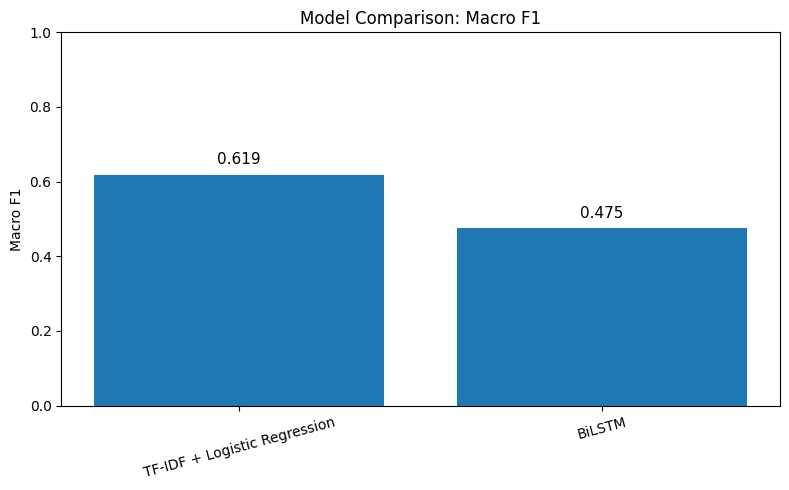

In [87]:
# ============================================
# Presentation Figure: Macro F1 Comparison
# ============================================

plot_data = final_comparison[
    final_comparison['Status'] == 'Implemented'
].copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_data['Model'],
    plot_data['Macro F1']
)

plt.title('Model Comparison: Macro F1')
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.xticks(rotation=15)

# Add values above bars
for bar, value in zip(bars, plot_data['Macro F1']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()